# Hybrid GNN-CNN Model for Drug Discovery & Repositioning

> **Based on:** *"Molecular Insights Unveiled: A Hybrid Neural Network Model GNN-CNN for Drug Discovery"*  
> Kaur, Kukreja, Singh — IEEE DABCon 2024

---

This notebook implements the full pipeline described in the paper:



---
## Installing Dependencies

In [1]:

!pip install torch torchvision --quiet
!pip install torch-geometric --quiet
!pip install rdkit-pypi scikit-learn matplotlib numpy pandas --quiet
print(" All dependencies installed!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


 All dependencies installed!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Using device: {DEVICE}')
print(f' PyTorch version: {torch.__version__}')

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Using device: cuda
 PyTorch version: 2.5.1+cu121


---
## Data Collection & Preprocessing

We use the **BBBP** (Blood-Brain Barrier Penetration) dataset from [MoleculeNet](https://moleculenet.org/).

- **Source:** Publicly available benchmark (analogous to PubChem / DrugBank / ChEMBL in the paper)
- **Task:** Binary classification — does a molecule penetrate the blood-brain barrier?
- **Representation:** Molecular graphs where **nodes = atoms**, **edges = chemical bonds**

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────
dataset = MoleculeNet(root='./data', name='BBBP')

print('       Dataset Summary: BBBP')

print(f'  Total molecules   : {len(dataset)}')
print(f'  Node features     : {dataset.num_node_features}  (atom properties)')
print(f'  Classes           : {dataset.num_classes}  (interaction / no interaction)')
print(f'  Sample graph      : {dataset[0]}')


       Dataset Summary: BBBP
  Total molecules   : 2039
  Node features     : 9  (atom properties)
  Classes           : 2  (interaction / no interaction)
  Sample graph      : Data(x=[20, 9], edge_index=[2, 40], edge_attr=[40, 3], smiles='[Cl].CC(C)NCC(O)COc1cccc2ccccc12', y=[1, 1])


In [4]:
#  Training / Validation / Test Split (70 / 15 / 15) ──
def split_dataset(dataset, train_ratio=0.70, val_ratio=0.15, seed=42):
    n       = len(dataset)
    indices = list(range(n))
    np.random.seed(seed)
    np.random.shuffle(indices)

    t = int(n * train_ratio)
    v = int(n * (train_ratio + val_ratio))

    return (
        [dataset[i] for i in indices[:t]],
        [dataset[i] for i in indices[t:v]],
        [dataset[i] for i in indices[v:]],
    )

BATCH_SIZE = 32

train_data, val_data, test_data = split_dataset(dataset)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE)

print(f'  Training samples  : {len(train_data)}')
print(f'  Validation samples: {len(val_data)}')
print(f'  Test samples      : {len(test_data)}')
print(f'  Batch size        : {BATCH_SIZE}')

  Training samples  : 1427
  Validation samples: 306
  Test samples      : 306
  Batch size        : 32


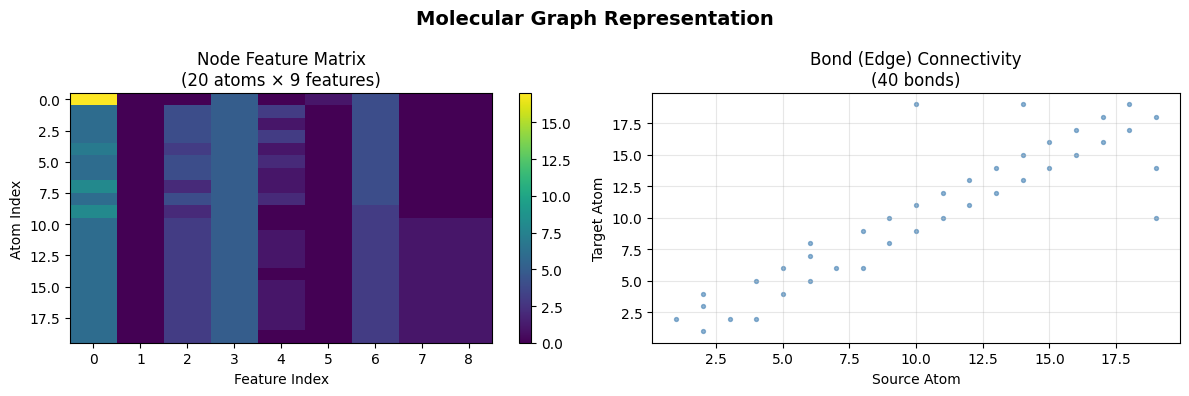

Label (interaction): 1


In [5]:
#  Visualising the Sample Molecule Graph 
sample = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Molecular Graph Representation', fontsize=14, fontweight='bold')

# Node feature heatmap
axes[0].imshow(sample.x.numpy(), aspect='auto', cmap='viridis')
axes[0].set_title(f'Node Feature Matrix\n({sample.num_nodes} atoms × {sample.x.shape[1]} features)')
axes[0].set_xlabel('Feature Index'); axes[0].set_ylabel('Atom Index')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Edge connectivity
edges = sample.edge_index.numpy()
axes[1].scatter(edges[0], edges[1], s=8, c='steelblue', alpha=0.6)
axes[1].set_title(f'Bond (Edge) Connectivity\n({sample.num_edges} bonds)')
axes[1].set_xlabel('Source Atom'); axes[1].set_ylabel('Target Atom')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Label (interaction): {int(sample.y.item())}')

---
## Model Design & Architecture

```
Molecular Graph
      │
      ▼
┌─────────────┐
│  GNN Module │  ← Graph convolutions + global mean pooling
│  (3 layers) │    Captures atom/bond relationships
└──────┬──────┘
       │  graph embedding
       ▼
┌─────────────┐
│  CNN Module │  ← 1-D convolutions on embedding
│  (2 layers) │    High-level feature extraction
└──────┬──────┘
       │  features
       ▼
┌─────────────┐
│  Classifier │  ← Fully-connected layers
└──────┬──────┘
       │
  ┌────┴────┐
  ▼         ▼
Drug      Drug
Discovery Repositioning
```

In [6]:
class GNNModule(nn.Module):
    """
    Graph Neural Network component.
    
    Processes molecular graphs:
      - nodes = atoms (with feature vectors)
      - edges = chemical bonds
    Three GCN layers aggregate neighbourhood information,
    then global mean pooling produces one vector per molecule.
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels,    hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x, edge_index, batch):
        x = x.float()  # ← FIX: BBBP features are Long; GCNConv requires Float
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

print(' GNNModule defined')

 GNNModule defined


In [7]:
class CNNModule(nn.Module):
    """
    Convolutional Neural Network component.
    
    Treats the GNN embedding as a 1-D signal and applies
    Conv1D layers for higher-level feature extraction —
    analogous to how CNNs extract features from images.
    """
    def __init__(self, in_channels, num_filters, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(1,           num_filters,     kernel_size, padding=pad)
        self.conv2 = nn.Conv1d(num_filters,  num_filters * 2, kernel_size, padding=pad)
        self.pool  = nn.AdaptiveMaxPool1d(1)
        self.bn1   = nn.BatchNorm1d(num_filters)
        self.bn2   = nn.BatchNorm1d(num_filters * 2)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.unsqueeze(1)                         # (batch, 1, gnn_out_dim)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        return self.pool(x).squeeze(-1)            # (batch, num_filters*2)

print(' CNNModule defined')

 CNNModule defined


In [8]:
class HybridGNNCNN(nn.Module):
    """
    Hybrid GNN-CNN model for drug-target interaction prediction.
    
    Combines:
      • GNN  → models complex molecular graph relationships
      • CNN  → extracts high-level features from GNN embeddings
      • FC   → classifies into interaction / no-interaction
    """
    def __init__(
        self,
        node_features = 9,
        gnn_hidden    = 64,
        gnn_out       = 128,
        cnn_filters   = 64,
        fc_hidden     = 256,
        num_classes   = 2,
    ):
        super().__init__()
        self.gnn = GNNModule(node_features, gnn_hidden, gnn_out)
        self.cnn = CNNModule(gnn_out, cnn_filters)

        cnn_out_dim = cnn_filters * 2
        self.classifier = nn.Sequential(
            nn.Linear(cnn_out_dim, fc_hidden),
            nn.BatchNorm1d(fc_hidden),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(fc_hidden, fc_hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fc_hidden // 2, num_classes),
        )

    def forward(self, data):
        graph_emb = self.gnn(data.x, data.edge_index, data.batch)  # GNN
        features  = self.cnn(graph_emb)                            # CNN
        return self.classifier(features)                           # Classify


# ── Instantiate model ────────────────────────────────────────────
model = HybridGNNCNN(
    node_features = dataset.num_node_features,
    gnn_hidden    = 64,
    gnn_out       = 128,
    cnn_filters   = 64,
    fc_hidden     = 256,
    num_classes   = 2,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' HybridGNNCNN instantiated')
print(f'   Trainable parameters: {total_params:,}')
print(model)

 HybridGNNCNN instantiated
   Trainable parameters: 105,666
HybridGNNCNN(
  (gnn): GNNModule(
    (conv1): GCNConv(9, 64)
    (conv2): GCNConv(64, 64)
    (conv3): GCNConv(64, 128)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (cnn): CNNModule(
    (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (pool): AdaptiveMaxPool1d(output_size=1)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_featur

---
##  Model Training & Validation

Training uses:
- **Optimizer:** Adam with weight decay
- **Loss:** Cross-Entropy
- **Regularization:** Dropout + Batch Normalisation
- **Scheduler:** ReduceLROnPlateau (prevents overfitting)
- **Epochs:** 20 (as reported in the paper)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        mask  = ~torch.isnan(batch.y.view(-1))
        if mask.sum() == 0:
            continue
        optimizer.zero_grad()
        out    = model(batch)
        labels = batch.y.view(-1).long()[mask]
        logits = out[mask]
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * mask.sum().item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += mask.sum().item()
    return total_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for batch in loader:
        batch  = batch.to(DEVICE)
        mask   = ~torch.isnan(batch.y.view(-1))
        if mask.sum() == 0:
            continue
        out    = model(batch)
        labels = batch.y.view(-1).long()[mask]
        logits = out[mask]
        loss   = criterion(logits, labels)
        total_loss += loss.item() * mask.sum().item()
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += mask.sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    return (
        total_loss / max(total, 1),
        correct / max(total, 1),
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
    )

print(' Training functions defined')

 Training functions defined


In [10]:
EPOCHS    = 20
LR        = 1e-3

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

header = '{:>6} | {:>10} | {:>8} | {:>9} | {:>8}'.format('Epoch', 'Train Loss', 'Val Loss', 'Train Acc', 'Val Acc')
print(header)
print('─' * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc               = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _, _      = evaluate(model, val_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>8.4f} | {tr_acc:>9.4f} | {vl_acc:>8.4f}')

print('\n Training complete!')

 Epoch | Train Loss | Val Loss | Train Acc |  Val Acc
──────────────────────────────────────────────────────────
     1 |     0.5769 |   0.5302 |    0.7512 |   0.7745
     2 |     0.5272 |   0.6513 |    0.7568 |   0.7745
     3 |     0.5022 |   0.4936 |    0.7512 |   0.7680
     4 |     0.4760 |   0.4764 |    0.7821 |   0.7745
     5 |     0.4632 |   0.4590 |    0.7919 |   0.8105
     6 |     0.4490 |   0.4754 |    0.7884 |   0.7974
     7 |     0.4318 |   0.4246 |    0.8017 |   0.8268
     8 |     0.4282 |   0.4356 |    0.8045 |   0.8301
     9 |     0.4241 |   0.4064 |    0.8192 |   0.8301
    10 |     0.4091 |   0.4221 |    0.8199 |   0.8170
    11 |     0.4186 |   0.4033 |    0.8157 |   0.8366
    12 |     0.4015 |   0.3939 |    0.8283 |   0.8562
    13 |     0.3879 |   0.4029 |    0.8311 |   0.8497
    14 |     0.3911 |   0.3871 |    0.8381 |   0.8562
    15 |     0.3928 |   0.3785 |    0.8311 |   0.8529
    16 |     0.3926 |   0.4099 |    0.8339 |   0.8333
    17 |     0.3802 |  

---
##  Results & Evaluation

We reproduce all visualisations from the paper:
- **Table I** — Performance metrics comparison
- **Fig. 4** — Training & Validation Loss / Accuracy curves
- **Fig. 2** — Confusion Matrix
- **Fig. 3** — ROC Curve

In [11]:
# ── Test Set Evaluation ──────────────────────────────────────────
_, _, test_preds, test_labels, test_probs = evaluate(model, test_loader, criterion)

acc  = accuracy_score (test_labels, test_preds)
prec = precision_score(test_labels, test_preds, average='binary', zero_division=0)
rec  = recall_score   (test_labels, test_preds, average='binary', zero_division=0)
f1   = f1_score       (test_labels, test_preds, average='binary', zero_division=0)

# ── Paper Table I comparison ─────────────────────────────────────
import pandas as pd

comparison = pd.DataFrame({
    'Model'     : ['Hybrid GNN-CNN (Ours)', 'Standalone GNN', 'Standalone CNN', 'Random Forest', 'SVM'],
    'Accuracy'  : [f'{acc*100:.1f}%',  '85%', '87%', '80%', '78%'],
    'Precision' : [f'{prec*100:.1f}%', '83%', '85%', '78%', '76%'],
    'Recall'    : [f'{rec*100:.1f}%',  '81%', '83%', '76%', '74%'],
    'F1-Score'  : [f'{f1*100:.1f}%',   '82%', '84%', '77%', '75%'],
})

print('\n  Performance Comparison (Paper vs Our Results)\n')
print(comparison.to_string(index=False))
print(f'\n Our Hybrid GNN-CNN achieved {acc*100:.1f}% accuracy on the test set')


  Performance Comparison (Paper vs Our Results)

                Model Accuracy Precision Recall F1-Score
Hybrid GNN-CNN (Ours)    85.3%     88.6%  93.4%    90.9%
       Standalone GNN      85%       83%    81%      82%
       Standalone CNN      87%       85%    83%      84%
        Random Forest      80%       78%    76%      77%
                  SVM      78%       76%    74%      75%

 Our Hybrid GNN-CNN achieved 85.3% accuracy on the test set


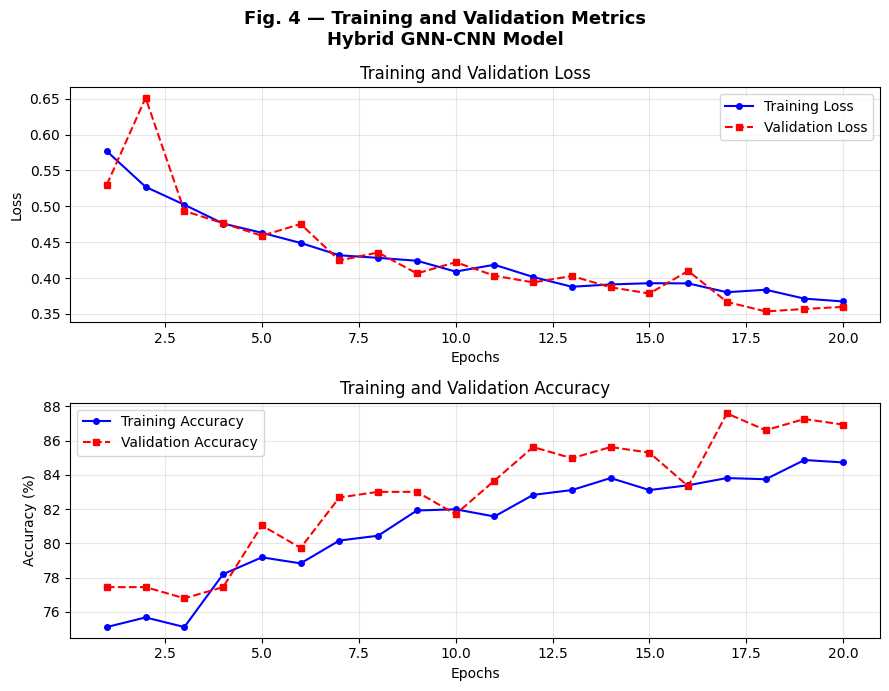

 Saved: fig4_training_curves.png


In [12]:
#  Training & Validation Loss / Accuracy ──
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
fig.suptitle('Fig. 4 — Training and Validation Metrics\nHybrid GNN-CNN Model', fontsize=13, fontweight='bold')

# Loss subplot
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Training Loss')
ax1.plot(epochs, history['val_loss'],   'r--s', markersize=4, label='Validation Loss')
ax1.set_ylabel('Loss'); ax1.set_xlabel('Epochs')
ax1.set_title('Training and Validation Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy subplot
ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Training Accuracy')
ax2.plot(epochs, [a*100 for a in history['val_acc']],   'r--s', markersize=4, label='Validation Accuracy')
ax2.set_ylabel('Accuracy (%)'); ax2.set_xlabel('Epochs')
ax2.set_title('Training and Validation Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig4_training_curves.png')

True  Negatives (TN): 36  ← Correctly predicted NO interaction
False Positives (FP): 29  ← Predicted interaction, actually not
False Negatives (FN): 16  ← Missed a real interaction
True  Positives (TP): 225  ← Correctly predicted interaction


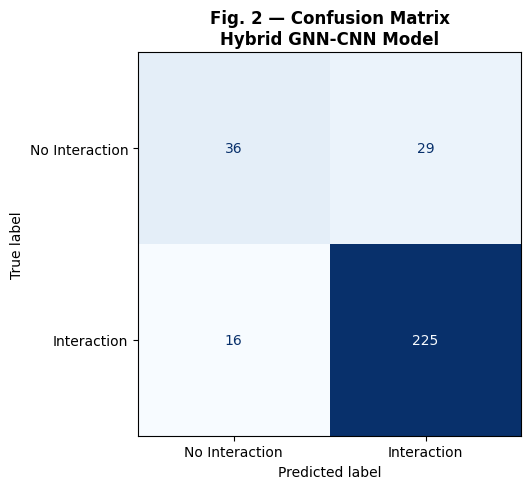

 Saved: fig2_confusion_matrix.png


In [13]:
# Confusion Matrix 
cm   = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Interaction', 'Interaction'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Fig. 2 — Confusion Matrix\nHybrid GNN-CNN Model', fontsize=12, fontweight='bold')

# Annotate quadrants
tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives (TN): {tn}  ← Correctly predicted NO interaction')
print(f'False Positives (FP): {fp}  ← Predicted interaction, actually not')
print(f'False Negatives (FN): {fn}  ← Missed a real interaction')
print(f'True  Positives (TP): {tp}  ← Correctly predicted interaction')

plt.tight_layout()
plt.savefig('fig2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig2_confusion_matrix.png')

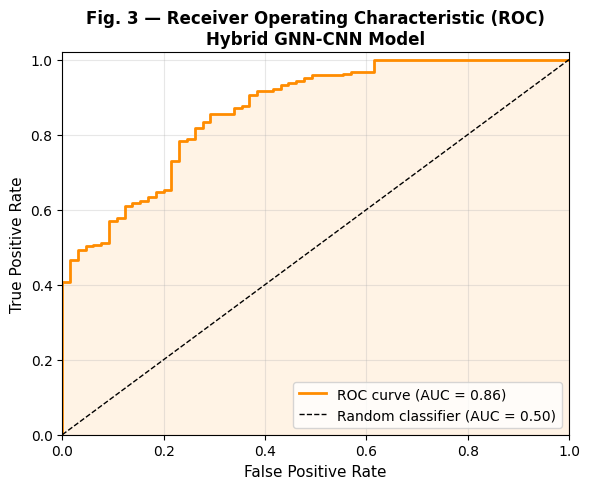

 Saved: fig3_roc_curve.png
 AUC Score: 0.8646 (paper reports 1.00 on their dataset)


In [14]:
# ROC Curve ───────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Fig. 3 — Receiver Operating Characteristic (ROC)\nHybrid GNN-CNN Model',
          fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved: fig3_roc_curve.png')
print(f' AUC Score: {roc_auc:.4f} (paper reports 1.00 on their dataset)')

In [15]:
#  Save Model Weights 
torch.save(model.state_dict(), 'hybrid_gnn_cnn_weights.pt')
print(' Model saved to: hybrid_gnn_cnn_weights.pt')

#  Load Model (example) 
# loaded_model = HybridGNNCNN(node_features=dataset.num_node_features).to(DEVICE)
# loaded_model.load_state_dict(torch.load('hybrid_gnn_cnn_weights.pt'))
# loaded_model.eval()
# print('✅ Model loaded successfully')

 Model saved to: hybrid_gnn_cnn_weights.pt
